In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("churn.csv")
print("shape:",df.shape)
df

shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [2]:
print(df.columns.tolist())
print("\nChurn Value count:")
print(df['Churn'].value_counts())
print("\nChurn Value percentage:")
print(df['Churn'].value_counts(normalize=True)*100)

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn Value count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Value percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### *Clearly the data is imbalanced*

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#cleaning data
df = df.drop("customerID",axis=1) #removing customerID
#changing totalcharges col into numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors="coerce")
#checking null vlaues after cahnging dtype
print("Null values:",df['TotalCharges'].isnull().sum())
#handling null values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
#checking if any null value is left
print("Null values after filling with median:", df['TotalCharges'].isnull().sum())
#encoding churn
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
print("cleaning is done!!")
print(df.shape)

Null values: 11
Null values after filling with median: 0
cleaning is done!!
(7043, 20)


In [6]:
#Encoding Categorical values
cat_cols = df.select_dtypes(include="object").columns.tolist() #selecting categorical columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df = df.astype(int)
print("dataset shape after encoding",df.shape)
df.head()

dataset shape after encoding (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [7]:
#separating x and y
x = df.drop("Churn",axis=1)
y = df['Churn']
print("Features",x.shape)
print("target",y.shape)

Features (7043, 30)
target (7043,)


In [8]:
# fixing imbalance datd using SMOTE
#SMOTE stands for Synthetic Minority Oversampling Technique. It creates artificial examples of the minority class (churners) so the model sees equal examples of both.
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split first, then apply SMOTE only on training data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
Churn
0    4138
1    1496
Name: count, dtype: int64

After SMOTE:
Churn
0    4138
1    4138
Name: count, dtype: int64


### *After using SMOTE data is balanced*

In [9]:
#Scaling features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_balanced)
x_test_scaled = scaler.transform(x_test)

print("Scaling done!")

Scaling done!


# *Training Model*

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Model1
lr = LogisticRegression(random_state=42)
lr.fit(x_train_scaled, y_train_balanced)
lr_pred = lr.predict(x_test_scaled)
lr_auc = roc_auc_score(y_test, lr.predict_proba(x_test_scaled)[:,1])

# Model2
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train_balanced)
rf_pred = rf.predict(x_test_scaled)
rf_auc = roc_auc_score(y_test, rf.predict_proba(x_test_scaled)[:,1])

#Model3
xgb = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb.fit(x_train_scaled, y_train_balanced)
xgb_pred = xgb.predict(x_test_scaled)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(x_test_scaled)[:,1])

print("Logistic Regression AUC Score:",round(lr_auc, 3))
print("RandomForestClassifier AUC Score:",round(rf_auc, 3))
print("XGBClassifier AUC Score:",round(xgb_auc, 3))

Logistic Regression AUC Score: 0.848
RandomForestClassifier AUC Score: 0.827
XGBClassifier AUC Score: 0.823


C:\Users\DELL\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:09:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [18]:
#Classification report
print("Final Model: Logistic Regression")
print("AUC Score:", round(lr_auc, 3))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Final Model: Logistic Regression
AUC Score: 0.848

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1036
           1       0.59      0.69      0.63       373

    accuracy                           0.79      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.79      0.79      1409



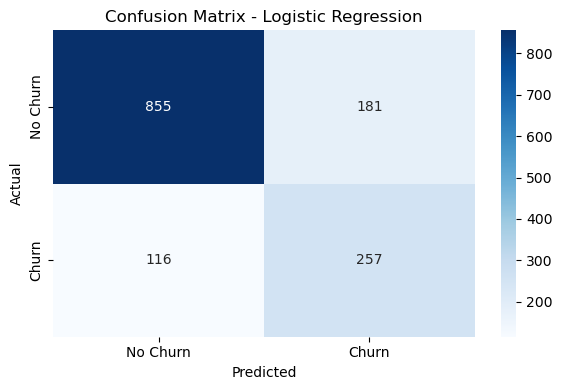

In [19]:
#Confusion Matrix
cm = confusion_matrix(y_test,lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
           xticklabels=["No Churn","Churn"],
           yticklabels=["No Churn","Churn"])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

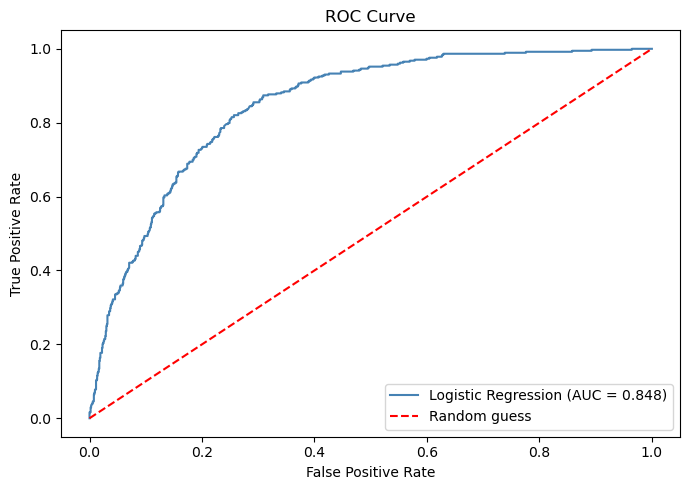

In [20]:
#ROC curve - closer the curve to left corner, better the model
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, lr.predict_proba(x_test_scaled)[:,1])

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'Logistic Regression (AUC = {round(lr_auc, 3)})')
plt.plot([0, 1], [0, 1], 'r--', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
!pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



Background dataset has 8276 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8276 when initializing the masker.


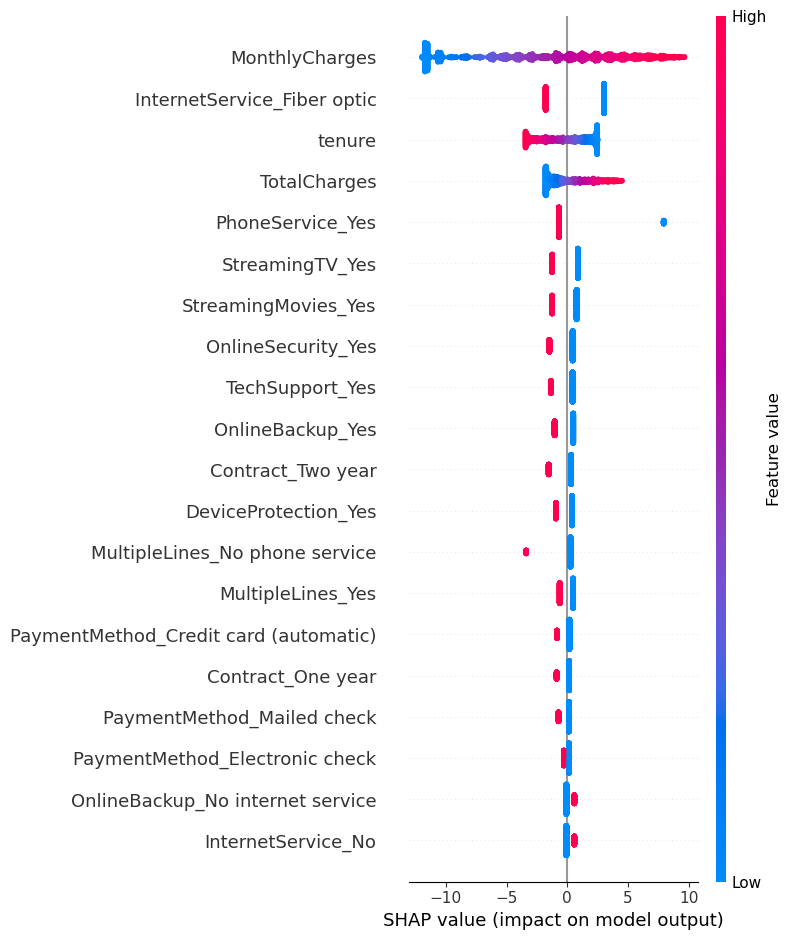

In [24]:
#SHAP values (why did the model predict churn?) This chart shows which features push predictions towards churn (red) or away from churn (blue).
import shap

explainer = shap.LinearExplainer(lr, x_train_scaled)
shap_values = explainer.shap_values(x_test_scaled)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, x_test_scaled,
                  feature_names=x.columns.tolist(),
                  show=False)
plt.tight_layout()
plt.show()